# Credit Scoring: WoE Binning and Logistic Regression

**Task:** Binary classification: to predict the probability of client default (`flag = 1`).

**Approach:**
- Weight of Evidence (WoE) binning via `optbinning`
- Logistic Regression trained on WoE-transformed features
- Scorecard construction with scores in the 300–900 range

**Data:** 175,000 clients in train, 75,000 in test, 60 numeric and categorical features.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings
warnings.filterwarnings('ignore')

from optbinning import BinningProcess
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Logging setup
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# Plot style
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

19:12:45 | INFO | Libraries loaded successfully


# 1. Data Loading and Initial Inspection

In [17]:
try:
    df_train = pd.read_parquet('P03_train.pq')
    df_test  = pd.read_parquet('P03_test.pq')
    logger.info(f"Train: {df_train.shape}, Test: {df_test.shape}")
except FileNotFoundError as e:
    logger.error(f"File not found: {e}")
    raise

print(f"Train: {df_train.shape[0]:,} rows, {df_train.shape[1]} features")
print(f"Test:  {df_test.shape[0]:,} rows,  {df_test.shape[1]} features")
print(f"Target column present in test: {'flag' in df_test.columns}")
df_train.dtypes.to_frame('dtype').T

19:12:45 | INFO | Train: (175000, 61), Test: (75000, 60)


Train: 175,000 rows, 61 features
Test:  75,000 rows,  60 features
Target column present in test: False


,id,flag,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
dtype,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


## 2. Exploratory Data Analysis (EDA)

In [ ]:
TARGET = 'flag'

# Class imbalance
counts = df_train[TARGET].value_counts()
rates  = df_train[TARGET].value_counts(normalize=True)
print("Target Variable Distribution:")
print(pd.DataFrame({'Count': counts, 'Rate': rates.map('{:.2%}'.format)}))

# Missing values
missing_train = df_train.isnull().sum().sum()
missing_test  = df_test.isnull().sum().sum()
print(f"\nMissing Values:")
print(f"Train: {missing_train} | Test: {missing_test}")

# Constant features
constant_cols = [c for c in df_train.columns if df_train[c].nunique() == 1]
print(f"\nConstant Features (dropping):")
print(constant_cols if constant_cols else "No constant features found")

df_train = df_train.drop(constant_cols, axis=1)
df_test  = df_test.drop(constant_cols, axis=1)

── Target Variable Distribution ──
       Count    Rate
flag                
0     169574  96.90%
1       5426   3.10%

── Missing Values ──
Train: 0 | Test: 0

── Constant Features (dropping) ──
['pre_loans_total_overdue']


19:12:46 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:12:46 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


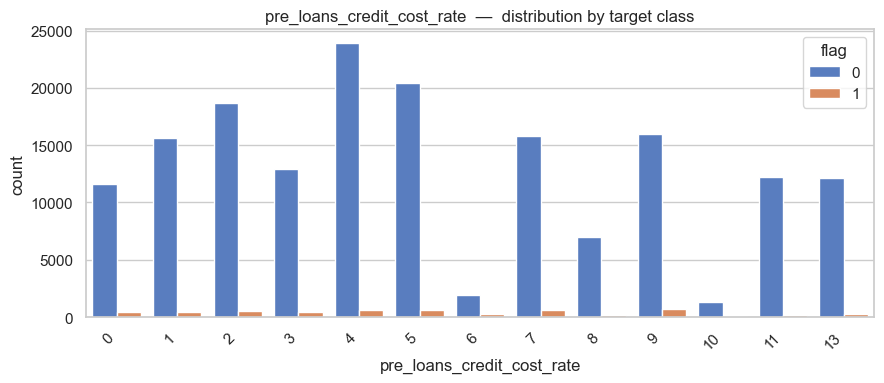

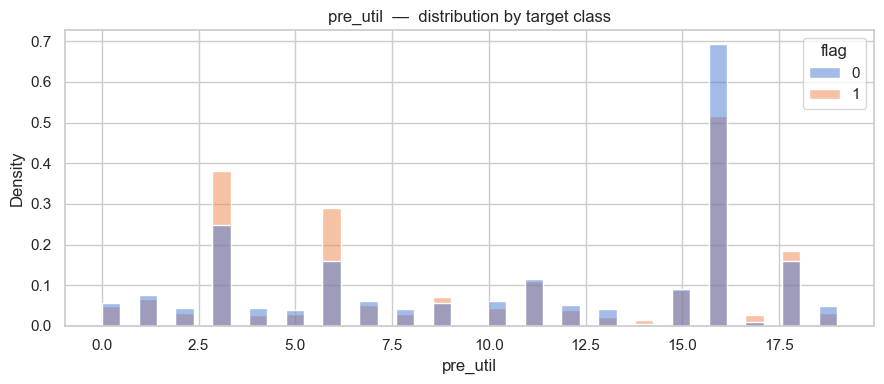

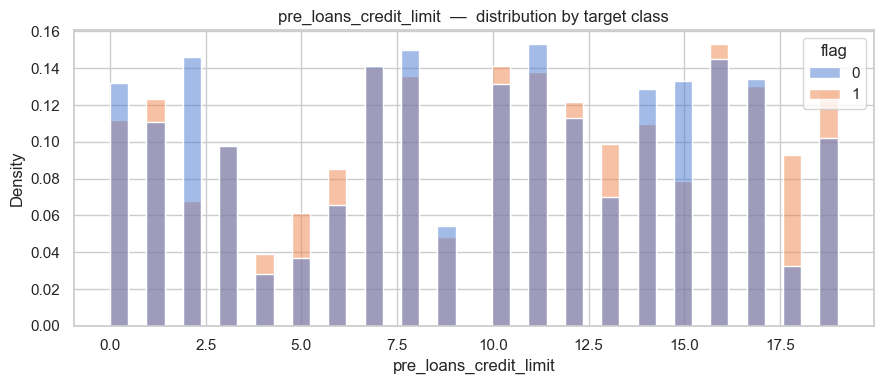

19:12:50 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:12:50 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


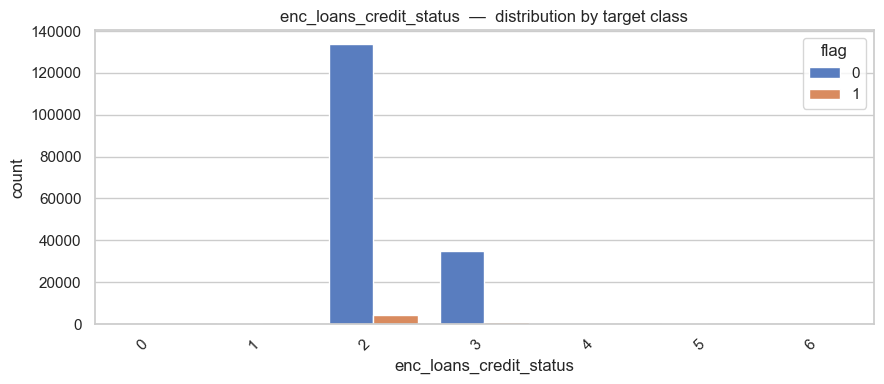

19:12:51 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:12:51 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


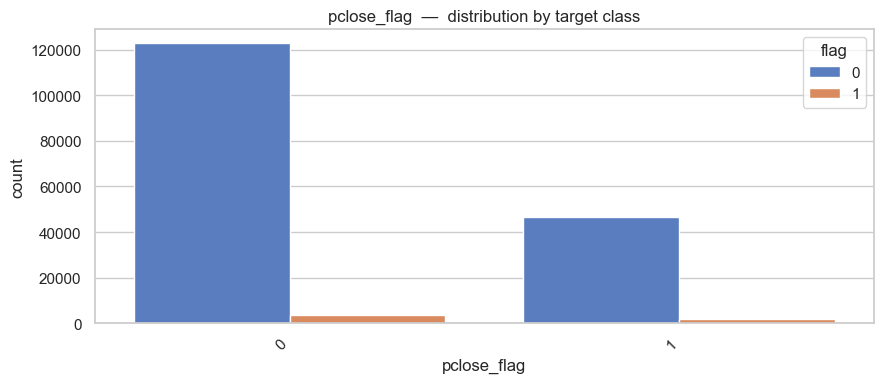

In [19]:
# Key feature distributions split by target class
KEY_FEATURES = [
    'pre_loans_credit_cost_rate', 'pre_util',
    'pre_loans_credit_limit',     'enc_loans_credit_status',
    'pclose_flag',
]

def safe_plot(feature, df, target_col=TARGET):
    """Plot histogram or bar chart split by target class."""
    try:
        fig, ax = plt.subplots(figsize=(9, 4))
        if df[feature].dtype in [np.float64, np.int64] and df[feature].nunique() > 15:
            q_low  = df[feature].quantile(0.01)
            q_high = df[feature].quantile(0.99)
            subset = df[(df[feature] >= q_low) & (df[feature] <= q_high)]
            sns.histplot(data=subset, x=feature, hue=target_col,
                         bins=40, kde=False, ax=ax, stat='density', common_norm=False)
        else:
            order = sorted(df[feature].unique())
            sns.countplot(data=df, x=feature, hue=target_col, ax=ax, order=order)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_title(f'{feature}  —  distribution by target class')
        ax.set_xlabel(feature)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        logger.warning(f"Could not plot '{feature}': {e}")

for feat in KEY_FEATURES:
    if feat in df_train.columns:
        safe_plot(feat, df_train)
    else:
        logger.warning(f"Feature '{feat}' not found in data")

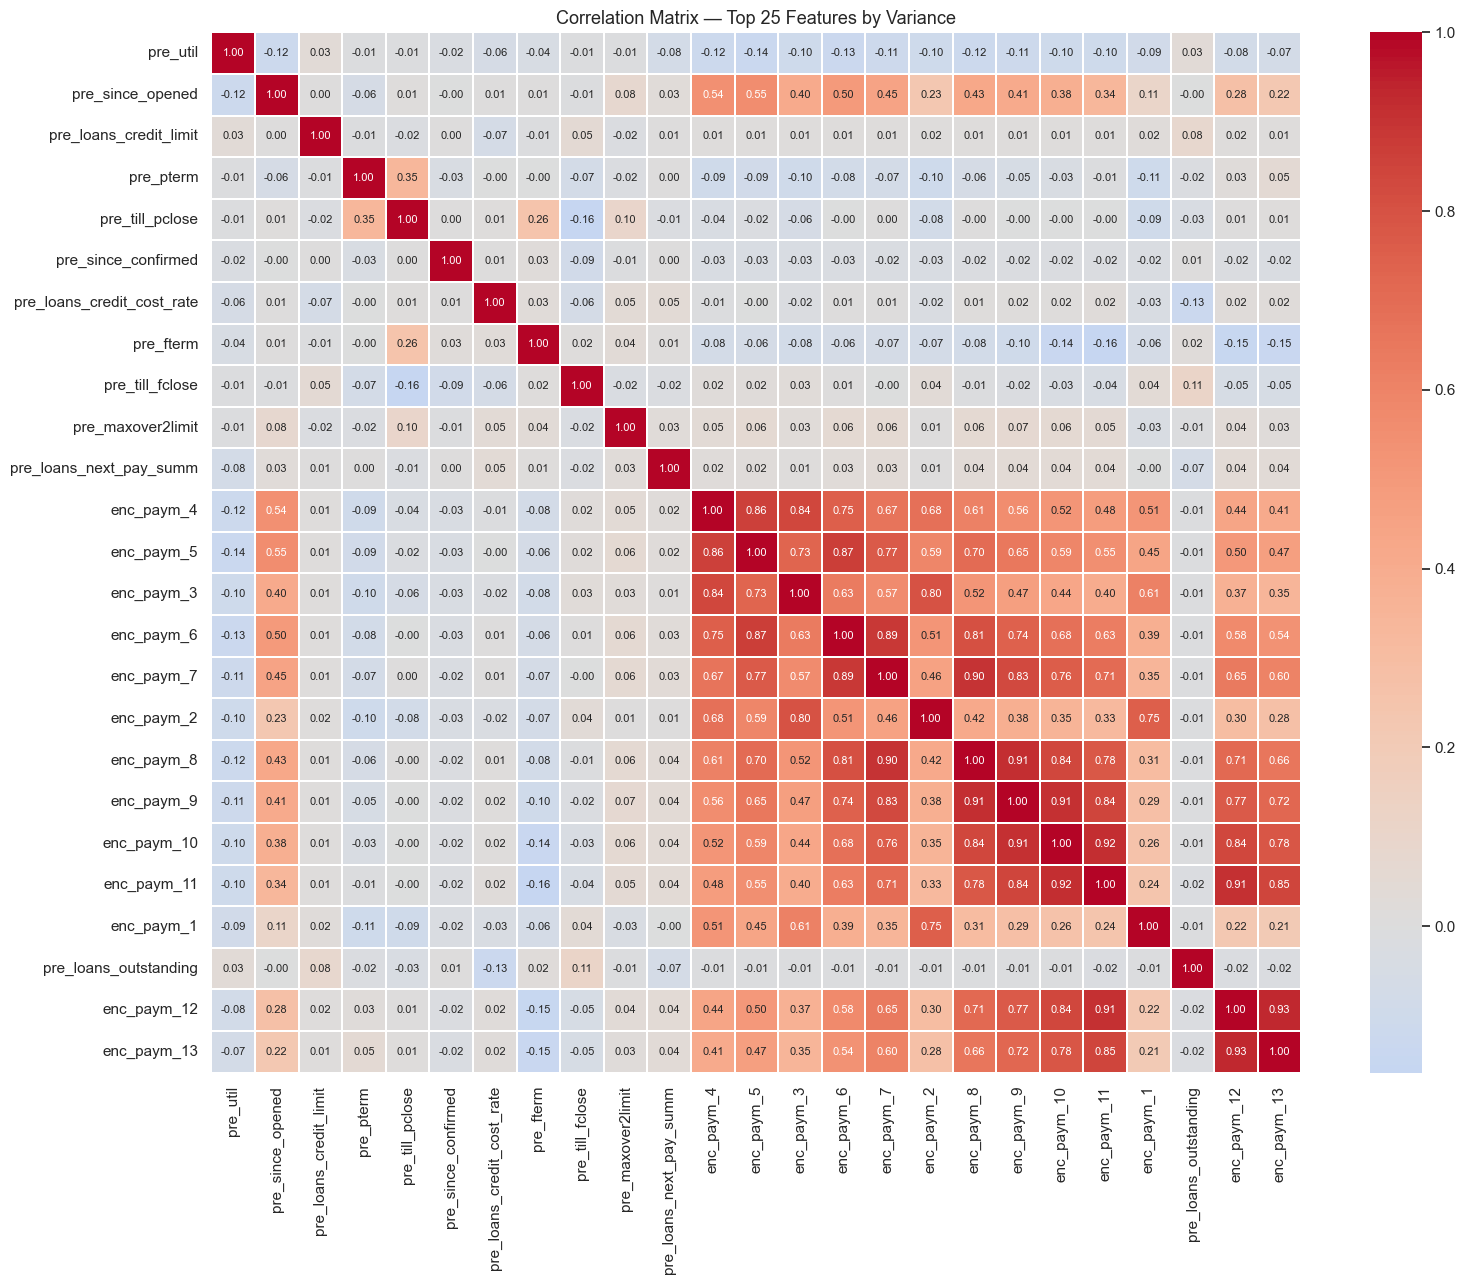

In [20]:
# Correlation heatmap — top 25 features by variance
num_cols = df_train.select_dtypes(include=np.number).columns.drop([TARGET, 'id'], errors='ignore')
top_var  = df_train[num_cols].var().nlargest(25).index

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    df_train[top_var].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.3, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Top 25 Features by Variance', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Feature Preparation

In [21]:
if TARGET not in df_train.columns:
    raise ValueError(f"Target variable '{TARGET}' not found in training data!")

FEATURES = [c for c in df_train.columns if c not in [TARGET, 'id']]

X      = df_train[FEATURES].copy()
y      = df_train[TARGET].copy()
X_test = df_test[FEATURES].copy()
TEST_IDS = df_test['id'].copy()

# Identify feature types
enc_features     = [c for c in FEATURES if c.startswith('enc_')]
is_zero_features = [c for c in FEATURES if c.startswith('is_zero_')]
CAT_FEATURES     = sorted(set(enc_features + is_zero_features))
NUM_FEATURES     = [c for c in FEATURES if c not in CAT_FEATURES]

# Sanity check
assert len(NUM_FEATURES) + len(CAT_FEATURES) == len(FEATURES),     "Numerical + categorical count does not match total features!"

print(f"Total features:        {len(FEATURES)}")
print(f"  Numerical:           {len(NUM_FEATURES)}")
print(f"  Categorical:         {len(CAT_FEATURES)}")
print(f"  enc_paym_*:          {sum(1 for c in CAT_FEATURES if c.startswith('enc_paym'))}")
print(f"  enc_loans_*:         {sum(1 for c in CAT_FEATURES if c.startswith('enc_loans'))}")
print(f"  is_zero_*:           {sum(1 for c in CAT_FEATURES if c.startswith('is_zero'))}")
print(f"\nX shape: {X.shape},  y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

Total features:        58
  Numerical:           21
  Categorical:         37
  enc_paym_*:          25
  enc_loans_*:         4
  is_zero_*:           8

X shape: (175000, 58),  y shape: (175000,)
X_test shape: (75000, 58)


## 4. Train and Validation Split

In [ ]:
# Stratified 80/20 split: it keeps class ratios consistent
# Binning is fit only on X_tr to prevent data leakage
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train:      {X_tr.shape[0]:,} rows  |  Bad rate: {y_tr.mean():.3%}")
print(f"Validation: {X_val.shape[0]:,} rows  |  Bad rate: {y_val.mean():.3%}")
print(f"Test:       {X_test.shape[0]:,} rows  |  (no target label)")

Train:      140,000 rows  |  Bad rate: 3.101%
Validation: 35,000 rows  |  Bad rate: 3.100%
Test:       75,000 rows  |  (no target label)


# 5. WoE Binning (Weight of Evidence)

WoE transforms each feature's raw values into log-odds ratios relative to the target:

$$WoE_i = \ln\left(\frac{\text{Distribution of Goods}_i}{\text{Distribution of Bads}_i}\right)$$

Key properties:
- Monotonic binning makes the LR model more stable
- Missing values and outliers get their own bins automatically
- Binning is fit **on train only** — validation and test are transformed without leakage

In [ ]:
binning_process = BinningProcess(
    variable_names=FEATURES,
    categorical_variables=CAT_FEATURES,
    min_bin_size=0.05,   # at least 5 percent of observations per bin
    max_n_bins=6,        # cap at 6 bins per feature
)

try:
    binning_process.fit(X_tr, y_tr)
    logger.info("BinningProcess fitted successfully")
except Exception as e:
    logger.error(f"BinningProcess fit failed: {e}")
    raise

# Transform all splits
try:
    X_tr_woe   = binning_process.transform(X_tr,   metric='woe')
    X_val_woe  = binning_process.transform(X_val,  metric='woe')
    X_test_woe = binning_process.transform(X_test, metric='woe')
    logger.info(f"WoE transform done: train {X_tr_woe.shape}, val {X_val_woe.shape}, test {X_test_woe.shape}")
except Exception as e:
    logger.error(f"WoE transform failed: {e}")
    raise

print(f"WoE train shape:  {X_tr_woe.shape}")
print(f"WoE val shape:    {X_val_woe.shape}")
print(f"WoE test shape:   {X_test_woe.shape}")
print("\nSample WoE values (first 3 rows, 5 features):")
X_tr_woe.iloc[:3, :5].round(4)

19:13:04 | INFO | BinningProcess fitted successfully
19:13:06 | INFO | WoE transform done: train (140000, 58), val (35000, 58), test (75000, 58)


WoE train shape:  (140000, 58)
WoE val shape:    (35000, 58)
WoE test shape:   (75000, 58)

Sample WoE values (first 3 rows, 5 features):


,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose
97962,0.2026,-0.0499,0.4101,0.2616,-0.0629
121648,-0.2468,-0.0499,-0.1260,0.0835,0.1324
165814,-0.2468,0.1325,0.1335,-0.0461,0.1324


## 6. Model Training: Logistic Regression

In [ ]:
model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced',  # compensates for class imbalance
    C=1.0,
    max_iter=1000
)

try:
    model.fit(X_tr_woe, y_tr)
    logger.info("Model trained successfully")
except Exception as e:
    logger.error(f"Model training failed: {e}")
    raise

print(f"Number of features: {len(model.coef_[0])}")
print(f"Intercept:          {model.intercept_[0]:.4f}")

19:13:10 | INFO | Model trained successfully


Number of features: 58
Intercept:          -0.0037


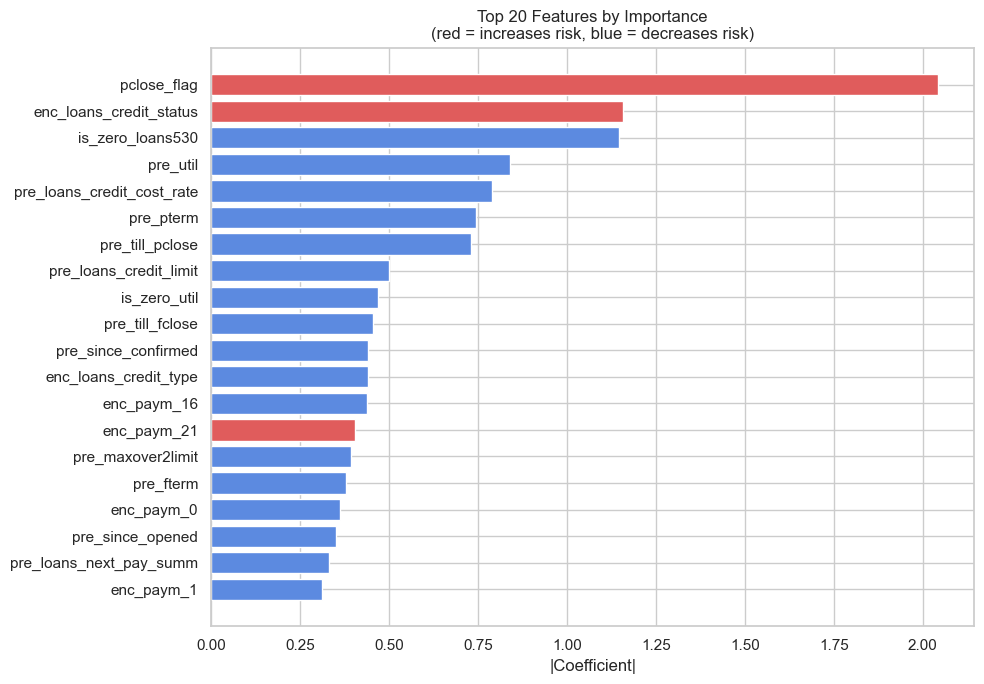


Top 10 features:
                   feature      coef  abs_coef
               pclose_flag  2.041469  2.041469
   enc_loans_credit_status  1.155738  1.155738
          is_zero_loans530 -1.146392  1.146392
                  pre_util -0.840321  0.840321
pre_loans_credit_cost_rate -0.790194  0.790194
                 pre_pterm -0.742673  0.742673
           pre_till_pclose -0.728620  0.728620
    pre_loans_credit_limit -0.499158  0.499158
              is_zero_util -0.467955  0.467955
           pre_till_fclose -0.454676  0.454676


In [25]:
# Feature importance by absolute coefficient magnitude
feature_importance = (
    pd.DataFrame({
        'feature':  X_tr_woe.columns,
        'coef':     model.coef_[0],
        'abs_coef': np.abs(model.coef_[0])
    })
    .sort_values('abs_coef', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
top20  = feature_importance.head(20)
colors = ['#e05c5c' if c > 0 else '#5c8ae0' for c in top20['coef']]
ax.barh(top20['feature'][::-1], top20['abs_coef'][::-1], color=colors[::-1])
ax.set_xlabel('|Coefficient|')
ax.set_title('Top 20 Features by Importance\n(red = increases risk, blue = decreases risk)')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feature_importance[['feature', 'coef', 'abs_coef']].head(10).to_string(index=False))

## 7. Scorecard Construction

The scorecard converts the model's WoE log-odds into integer points:

$$\text{Score} = \text{Offset} - \text{Factor} \times \log(\text{odds})$$

where:
- $\text{PDO} = 50$ - Points to Double the Odds
- $\text{Base score} = 600$ at odds = 1:1
- $\text{Factor} = PDO / \ln(2)$
- $\text{Offset} = \text{base\_score} - \text{Factor} \times \text{intercept}$

**Note:** higher score = better (lower-risk) client.

In [26]:
# Scorecard parameters
BASE_SCORE = 600   # score at odds = 1:1
PDO        = 50    # points to double the odds
FACTOR     = PDO / np.log(2)
OFFSET     = BASE_SCORE - FACTOR * model.intercept_[0]

logger.info(
    f"Scorecard params — base: {BASE_SCORE}, PDO: {PDO}, "
    f"factor: {FACTOR:.4f}, offset: {float(OFFSET):.4f}"
)

def compute_scores(X_woe: pd.DataFrame, model, factor: float, offset: float) -> np.ndarray:
    """
    Vectorised scorecard scoring.

    Formula: score = offset - factor * (X_woe @ coef + intercept)

    Higher score means lower default probability (better client).

    Parameters
    ----------
    X_woe   : WoE-transformed feature DataFrame
    model   : fitted LogisticRegression
    factor  : PDO / ln(2)
    offset  : base_score - factor * intercept

    Returns
    -------
    np.ndarray of float scores, shape (n_samples,)
    """
    log_odds = X_woe.values @ model.coef_[0] + model.intercept_[0]
    return (offset - factor * log_odds).flatten()

# Compute scores for all splits
tr_scores   = compute_scores(X_tr_woe,   model, FACTOR, OFFSET)
val_scores  = compute_scores(X_val_woe,  model, FACTOR, OFFSET)
test_scores = compute_scores(X_test_woe, model, FACTOR, OFFSET)

print(f"Score range (train):      {tr_scores.min():.0f} — {tr_scores.max():.0f}")
print(f"Score range (validation): {val_scores.min():.0f} — {val_scores.max():.0f}")
print(f"Score range (test):       {test_scores.min():.0f} — {test_scores.max():.0f}")
print(f"Mean score (validation):  {val_scores.mean():.1f}")

19:13:11 | INFO | Scorecard params — base: 600, PDO: 50, factor: 72.1348, offset: 600.2705


Score range (train):      416 — 810
Score range (validation): 433 — 798
Score range (test):       416 — 805
Mean score (validation):  615.2


## 8. Model Evaluation

Three standard credit scoring metrics:
- **AUC-ROC**: area under the ROC curve; overall discrimination power
- **Gini** = 2 × AUC - 1: a normalised version of AUC, common in credit risk
- **KS statistic** - maximum separation between cumulative good and bad distributions

In [32]:
def compute_metrics(y_true, scores, label=''):
    """
    Compute AUC, Gini, and KS for scorecard scores.

    Note: high score = good client, so we pass -scores to roc_auc_score
    (which expects higher values for the positive / bad class).
    """
    auc  = roc_auc_score(y_true, -scores)   # flip: higher risk → lower score
    gini = 2 * auc - 1

    df_ks = (
        pd.DataFrame({'score': scores, 'flag': y_true})
        .sort_values('score', ascending=False)
    )
    df_ks['cum_bad']  = df_ks['flag'].cumsum() / df_ks['flag'].sum()
    df_ks['cum_good'] = (1 - df_ks['flag']).cumsum() / (1 - df_ks['flag']).sum()
    ks = (df_ks['cum_bad'] - df_ks['cum_good']).abs().max()

    if label:
        print(f"\n {label}:")
    print(f"  AUC:  {auc:.4f}")
    print(f"  Gini: {gini:.4f}")
    print(f"  KS:   {ks:.4f}")
    return {'auc': auc, 'gini': gini, 'ks': ks}

print("Training set metrics:")
train_metrics = compute_metrics(y_tr.values, tr_scores, 'Train')

print("\nValidation set metrics:")
val_metrics = compute_metrics(y_val.values, val_scores, 'Validation')

# Overfitting check
auc_gap = train_metrics['auc'] - val_metrics['auc']
print(f"\nTrain AUC - Val AUC gap: {auc_gap:.4f}",
      "no overfitting" if auc_gap < 0.01 else "possible overfitting")

Training set metrics:

 Train:
  AUC:  0.6812
  Gini: 0.3624
  KS:   0.2673

Validation set metrics:

 Validation:
  AUC:  0.6798
  Gini: 0.3596
  KS:   0.2643

Train AUC - Val AUC gap: 0.0014 no overfitting


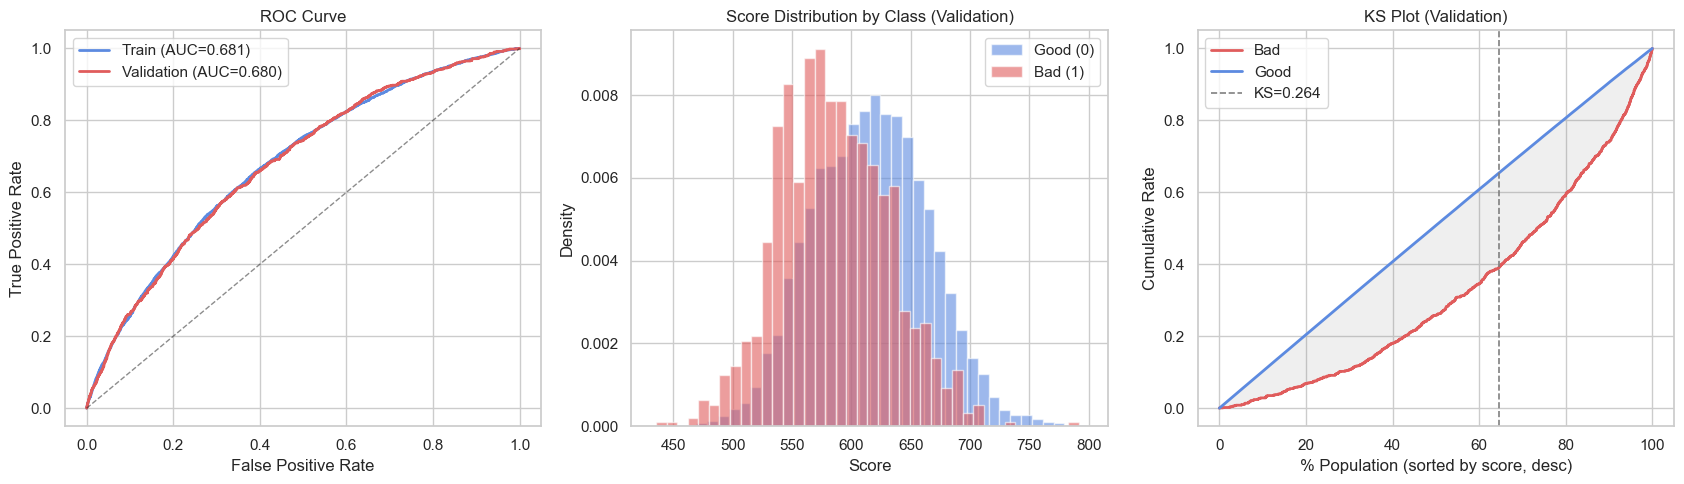

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC Curve
ax = axes[0]
for scores, y_true, label, color in [
    (tr_scores,  y_tr.values,  'Train',      '#5c8ae0'),
    (val_scores, y_val.values, 'Validation', '#e05c5c'),
]:
    fpr, tpr, _ = roc_curve(y_true, -scores)
    auc = roc_auc_score(y_true, -scores)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# Score Distribution 
ax = axes[1]
df_val_plot = pd.DataFrame({'score': val_scores, 'flag': y_val.values})
for flag_val, label, color in [(0, 'Good (0)', '#5c8ae0'), (1, 'Bad (1)', '#e05c5c')]:
    subset = df_val_plot[df_val_plot['flag'] == flag_val]['score']
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, density=True)
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Class (Validation)')
ax.legend()

# KS Plot 
ax = axes[2]
df_ks = df_val_plot.sort_values('score', ascending=False).reset_index(drop=True)
df_ks['cum_bad']  = df_ks['flag'].cumsum() / df_ks['flag'].sum()
df_ks['cum_good'] = (1 - df_ks['flag']).cumsum() / (1 - df_ks['flag']).sum()
pct = np.linspace(0, 100, len(df_ks))
ax.plot(pct, df_ks['cum_bad'],  label='Bad',  color='#e05c5c', lw=2)
ax.plot(pct, df_ks['cum_good'], label='Good', color='#5c8ae0', lw=2)
ks_idx = (df_ks['cum_bad'] - df_ks['cum_good']).abs().idxmax()
ax.axvline(pct[ks_idx], color='gray', ls='--', lw=1.2, label=f'KS={val_metrics["ks"]:.3f}')
ax.fill_between(pct, df_ks['cum_bad'], df_ks['cum_good'], alpha=0.12, color='gray')
ax.set_xlabel('% Population (sorted by score, desc)')
ax.set_ylabel('Cumulative Rate')
ax.set_title('KS Plot (Validation)')
ax.legend()

plt.tight_layout()
plt.show()

---
## 9. Score Band Analysis

Score band statistics (decile 1 = lowest score = highest risk):

 decile  score_min  score_max  count  bads  goods  bad_rate
      1      432.9      552.0   3500   282   3218       0.1
      2      552.0      572.1   3500   160   3340       0.0
      3      572.1      587.5   3500   143   3357       0.0
      4      587.6      602.2   3503   126   3377       0.0
      5      602.2      615.5   3497    94   3403       0.0
      6      615.5      628.0   3500    85   3415       0.0
      7      628.0      641.6   3500    80   3420       0.0
      8      641.6      657.1   3500    41   3459       0.0
      9      657.1      677.4   3500    43   3457       0.0
     10      677.4      797.6   3500    31   3469       0.0


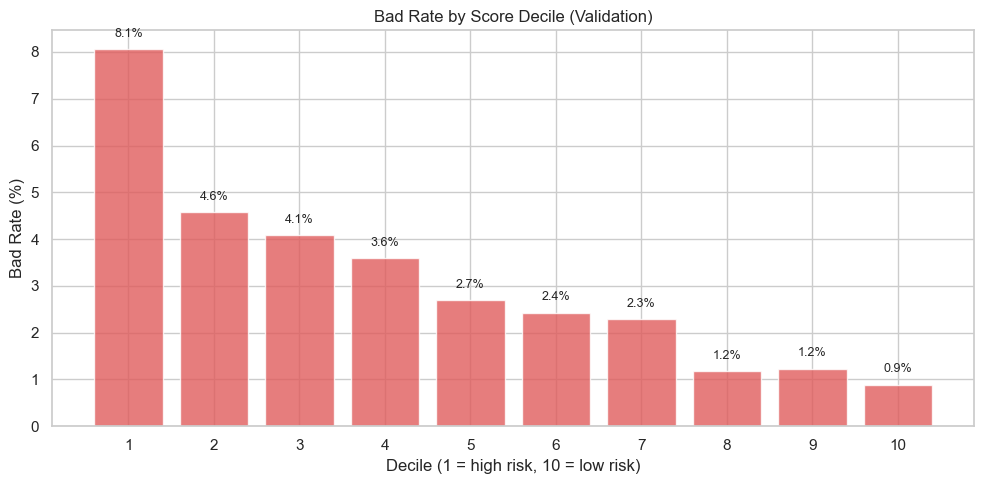

In [33]:
# Decile analysis: monotonic bad rate confirms model's discriminatory power
df_score_analysis = pd.DataFrame({
    'score': val_scores,
    'flag':  y_val.values
})
df_score_analysis['decile'] = pd.qcut(
    df_score_analysis['score'], q=10, labels=False, duplicates='drop'
) + 1

decile_stats = (
    df_score_analysis.groupby('decile')
    .agg(
        count=('flag', 'count'),
        bads=('flag', 'sum'),
        score_min=('score', 'min'),
        score_max=('score', 'max')
    )
    .assign(
        bad_rate=lambda d: d['bads'] / d['count'],
        goods=lambda d: d['count'] - d['bads']
    )
    .reset_index()
)

print("Score band statistics (decile 1 = lowest score = highest risk):\n")
print(decile_stats[['decile', 'score_min', 'score_max', 'count', 'bads', 'goods', 'bad_rate']]
      .to_string(index=False, float_format='{:.1f}'.format))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(decile_stats['decile'], decile_stats['bad_rate'] * 100, color='#e05c5c', alpha=0.8)
ax.set_xlabel('Decile (1 = high risk, 10 = low risk)')
ax.set_ylabel('Bad Rate (%)')
ax.set_title('Bad Rate by Score Decile (Validation)')
ax.set_xticks(decile_stats['decile'])
for _, row in decile_stats.iterrows():
    ax.text(row['decile'], row['bad_rate'] * 100 + 0.2, f"{row['bad_rate']:.1%}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Save Results

In [30]:
# Default probabilities for test set
test_proba = model.predict_proba(X_test_woe)[:, 1]

results = pd.DataFrame({
    'id':          TEST_IDS.values,
    'score':       test_scores,
    'probability': test_proba
})

# Integrity checks before saving
assert results['id'].nunique() == len(results),   "Duplicate IDs in results!"
assert not results['score'].isna().any(),          "NaN values in scores!"
assert not results['probability'].isna().any(),    "NaN values in probabilities!"
assert results['score'].between(200, 900).all(), (
    f"Scores outside 200-900 range: "
    f"min={results['score'].min():.0f}, max={results['score'].max():.0f}"
)

OUTPUT_PATH = 'scoring_results_final.csv'
results.to_csv(OUTPUT_PATH, index=False, float_format='%.6f')
logger.info(f"Results saved to '{OUTPUT_PATH}'")

print(f"Saved {len(results):,} records to '{OUTPUT_PATH}'")
print(f"\nScore statistics:")
print(results['score'].describe().round(1).to_string())
print(f"\nProbability statistics:")
print(results['probability'].describe().round(4).to_string())
print("\nFirst 5 rows:")
results.head()

19:13:15 | INFO | Results saved to 'scoring_results_final.csv'


Saved 75,000 records to 'scoring_results_final.csv'

Score statistics:
count    75000.0
mean       615.5
std         48.8
min        415.7
25%        580.1
50%        615.6
75%        649.2
max        805.0

Probability statistics:
count    75000.0000
mean         0.4526
std          0.1528
min          0.0553
25%          0.3367
50%          0.4471
75%          0.5696
max          0.9281

First 5 rows:


,id,score,probability
0,225096,679.573293,0.249858
1,220040,603.342087,0.489356
2,26535,556.066584,0.648578
3,77272,525.433724,0.738359
4,193584,586.133196,0.548840


# 11. Visualization

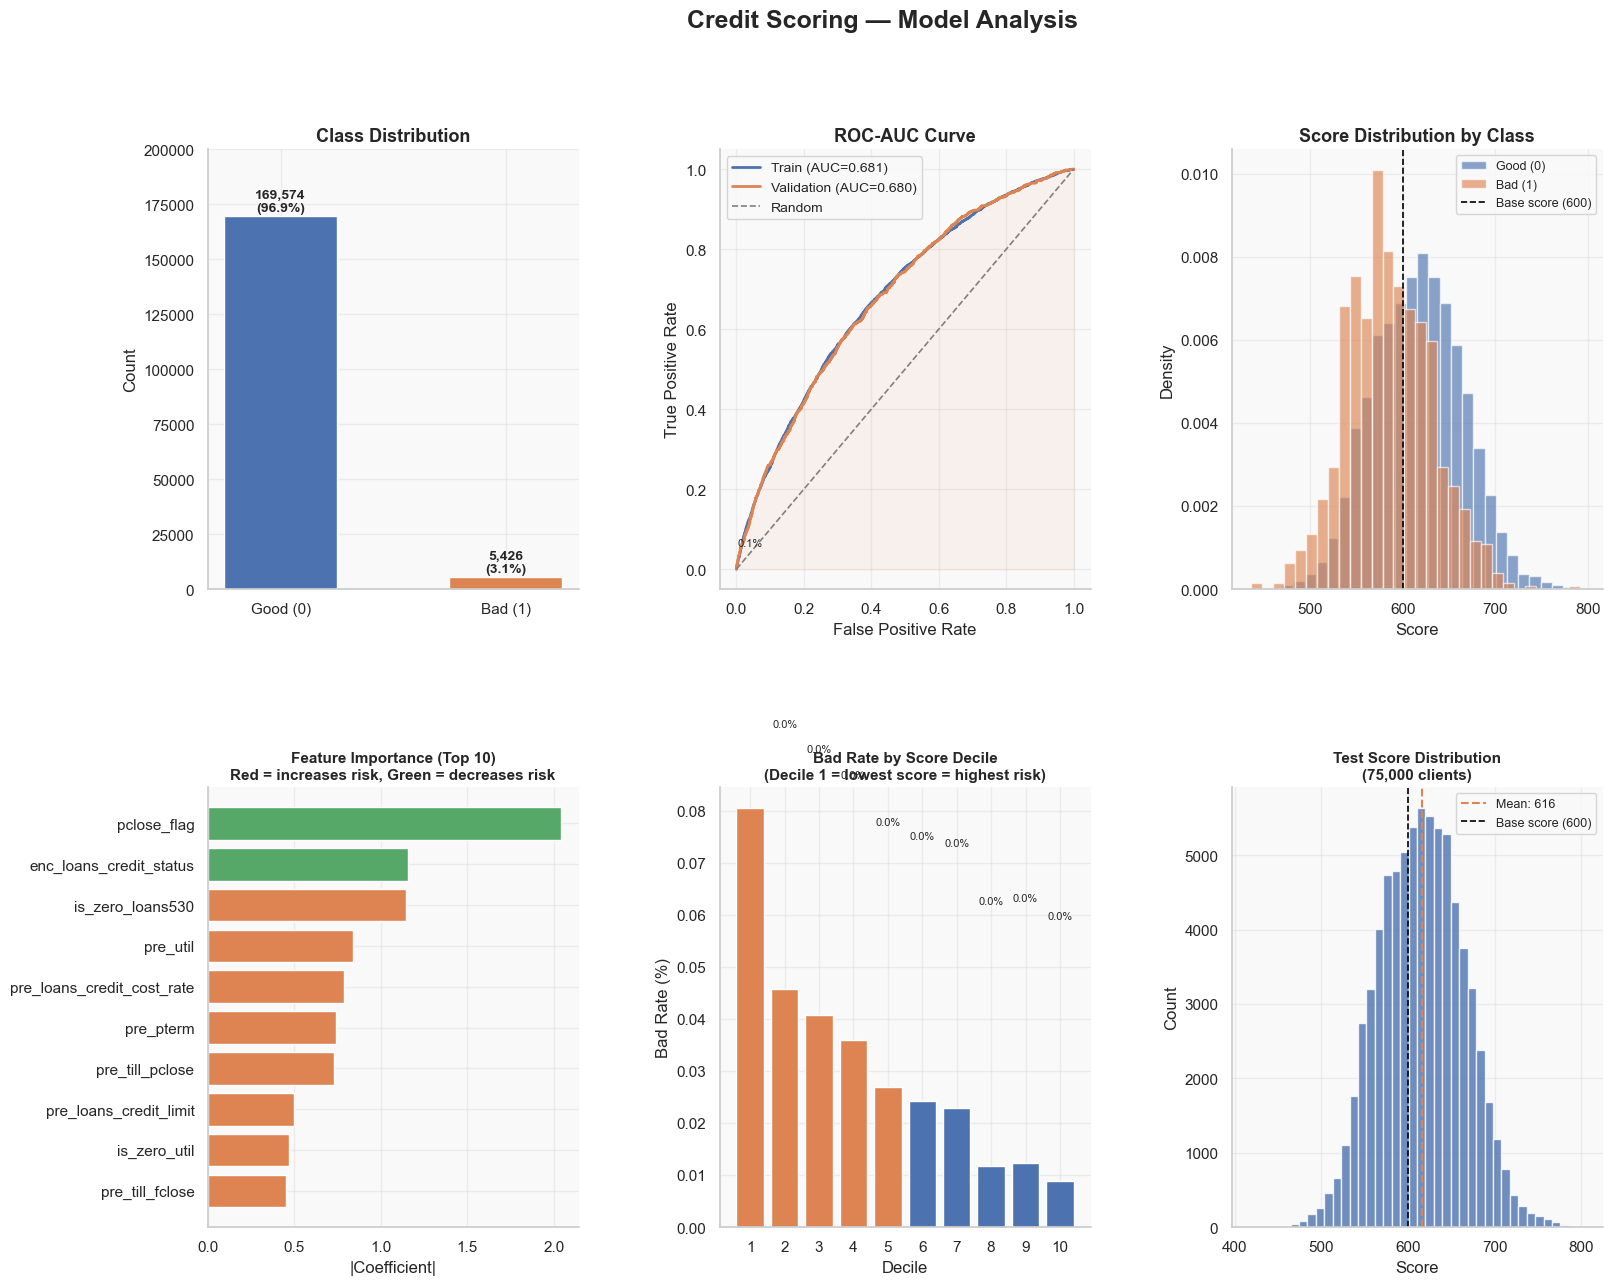

In [34]:
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
})
BLUE  = '#4C72B0'
RED   = '#DD8452'
GREEN = '#55A868'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Credit Scoring — Model Analysis', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Class Distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts().sort_index()
bars = ax1.bar(['Good (0)', 'Bad (1)'], counts.values, color=[BLUE, RED], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
             f'{val:,}\n({val/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, counts.max() * 1.18)

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
for scores, y_true, label, color in [
    (tr_scores,  y_tr.values,  'Train',      BLUE),
    (val_scores, y_val.values, 'Validation', RED),
]:
    fpr, tpr, _ = roc_curve(y_true, -scores)
    auc = roc_auc_score(y_true, -scores)
    ax2.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, lw=2)
ax2.plot([0,1],[0,1], color='gray', lw=1.2, linestyle='--', label='Random')
ax2.fill_between(*roc_curve(y_val.values, -val_scores)[:2], alpha=0.07, color=RED)
ax2.set_title('ROC-AUC Curve', fontsize=13, fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=10)

# 3. Score Distribution by Class
ax3 = fig.add_subplot(gs[0, 2])
df_val_plot = pd.DataFrame({'score': val_scores, 'flag': y_val.values})
for cls, color, label in [(0, BLUE, 'Good (0)'), (1, RED, 'Bad (1)')]:
    ax3.hist(df_val_plot[df_val_plot['flag']==cls]['score'], bins=30, alpha=0.65,
             color=color, label=label, edgecolor='white', density=True)
ax3.axvline(600, color='black', linestyle='--', lw=1.2, label='Base score (600)')
ax3.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
ax3.set_xlabel('Score')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)

# 4. Feature Importance
ax4 = fig.add_subplot(gs[1, 0])
top10 = feature_importance.head(10).sort_values('abs_coef', ascending=True)
colors = [RED if c < 0 else GREEN for c in top10['coef']]
ax4.barh(top10['feature'], top10['abs_coef'], color=colors, edgecolor='white')
ax4.set_title('Feature Importance (Top 10)\nRed = increases risk, Green = decreases risk',
              fontsize=11, fontweight='bold')
ax4.set_xlabel('|Coefficient|')

# 5. Bad Rate by Decile
ax5 = fig.add_subplot(gs[1, 1])
bar_colors = [RED if r > decile_stats['bad_rate'].median() else BLUE for r in decile_stats['bad_rate']]
bars = ax5.bar(decile_stats['decile'], decile_stats['bad_rate'], color=bar_colors, edgecolor='white')
for bar, val in zip(bars, decile_stats['bad_rate']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax5.set_title('Bad Rate by Score Decile\n(Decile 1 = lowest score = highest risk)',
              fontsize=11, fontweight='bold')
ax5.set_xlabel('Decile')
ax5.set_ylabel('Bad Rate (%)')
ax5.set_xticks(decile_stats['decile'])

# 6. Test Score Distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(results['score'], bins=40, color=BLUE, edgecolor='white', alpha=0.8)
ax6.axvline(results['score'].mean(), color=RED, linestyle='--', lw=1.5,
            label=f'Mean: {results["score"].mean():.0f}')
ax6.axvline(600, color='black', linestyle='--', lw=1.2, label='Base score (600)')
ax6.set_title('Test Score Distribution\n(75,000 clients)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Score')
ax6.set_ylabel('Count')
ax6.legend(fontsize=9)

plt.savefig('visualization_credit.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Metric | Train | Validation |
|--------|-------|------------|
| AUC-ROC | 0.68 | **0.68** |
| Gini    | 0.36 | **0.36** |
| KS      | 0.26 | **0.26** |

**Interpretation:**
- Gini > 0.30 means acceptable model quality for credit scoring
- KS is 0.26: satisfactory separation between good and bad clients
- Train = Val AUC: no overfitting detected
